In [110]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import xarray as xr
import os
from tqdm.auto import tqdm
import time
import json
from datetime import datetime, timedelta
import csv

## Read in FL shp

In [4]:
county = gpd.read_file('data/Shapefile/tl_2019_12_county_coastal.shp')
tract = gpd.read_file('data/Shapefile/tl_2019_12_tract_coastal.shp')
tract_centroids = gpd.read_file('data/Shapefile/tl_2019_12_tract_coastal_centroids.shp')

In [5]:
print(f'There are {len(county)} coastal counties')
print(f'There are {len(tract)} coastal tracts')

There are 35 coastal counties
There are 3305 coastal tracts


## Read in weeks

In [82]:
# Read in all the weeks data from the STU
weeks = pd.read_csv('data/STU/Weeks_2019-2023.csv')

In [92]:
# Generate a lookup table between dates and weeks
week_table = []
for week in weeks['week']:
    start_date = datetime.strptime(week, '%Y-%m-%d')
    dates = [(start_date + timedelta(days=i)).strftime('%Y-%m-%d') for i in range(7)]
    temp = pd.DataFrame({'day': dates, 'week': [week]*7})
    week_table.append(temp)
week_table = pd.concat(week_table, ignore_index=True)

In [93]:
week_table

,day,week
0,2019-01-07,2019-01-07
1,2019-01-08,2019-01-07
2,2019-01-09,2019-01-07
3,2019-01-10,2019-01-07
4,2019-01-11,2019-01-07
...,...,...
1815,2023-12-27,2023-12-25
1816,2023-12-28,2023-12-25
1817,2023-12-29,2023-12-25
1818,2023-12-30,2023-12-25


## Examine the NetCDF file

The raw data was downloaded from https://www.climatologylab.org/gridmet.html

Here, we take an example NetCDF file and examine the dataset format before we process all datasets.

In [115]:
ds = xr.open_dataset('data/gridMET/vs_2019.nc') # The raw data is not uploaded to GitHub
ds

<xarray.Dataset> Size: 2GB
Dimensions:     (day: 365, lat: 585, lon: 1386, crs: 1)
Coordinates:
  * day         (day) datetime64[ns] 3kB 2019-01-01 2019-01-02 ... 2019-12-31
  * lat         (lat) float64 5kB 49.4 49.36 49.32 49.28 ... 25.15 25.11 25.07
  * lon         (lon) float64 11kB -124.8 -124.7 -124.7 ... -67.14 -67.1 -67.06
  * crs         (crs) uint16 2B 3
Data variables:
    wind_speed  (day, lat, lon) float64 2GB ...
Attributes: (12/19)
    geospatial_bounds_crs:      EPSG:4326
    Conventions:                CF-1.6
    geospatial_bounds:          POLYGON((-124.7666666333333 49.40000000000000...
    geospatial_lat_min:         25.066666666666666
    geospatial_lat_max:         49.40000000000000
    geospatial_lon_min:         -124.7666666333333
    ...                         ...
    date:                       02 March 2020
    note1:                      The projection information for this file is: ...
    note2:                      Citation: Abatzoglou, J.T., 2013, Development...
    note3:                      Data in slices after last_permanent_slice (1-...
    note4:                      Data in slices after last_provisional_slice (...
    note5:                      Days correspond approximately to calendar day...

In [60]:
# Take a subset that locates in FL spatial extent
subset = ds.sel(
    lat=slice(31.1, 24), # Notice the lat is descending
    lon=slice(-88, -79.5),
    day='2019-01-01'
)
df = subset['precipitation_amount'].to_dataframe().reset_index()
geometry = [Point(xy) for xy in zip(df['lon'], df['lat'])]
gdf = gpd.GeoDataFrame(df, geometry=geometry).set_crs(epsg=4326)
display(gdf)

,lat,lon,day,precipitation_amount,geometry
0,31.066667,-87.975000,2019-01-01,8.2,POINT (-87.975 31.06667)
1,31.066667,-87.933333,2019-01-01,9.7,POINT (-87.93333 31.06667)
2,31.066667,-87.891667,2019-01-01,10.8,POINT (-87.89167 31.06667)
3,31.066667,-87.850000,2019-01-01,11.8,POINT (-87.85 31.06667)
4,31.066667,-87.808333,2019-01-01,12.7,POINT (-87.80833 31.06667)
...,...,...,...,...,...
29575,25.066667,-79.683333,2019-01-01,NaN,POINT (-79.68333 25.06667)
29576,25.066667,-79.641667,2019-01-01,NaN,POINT (-79.64167 25.06667)
29577,25.066667,-79.600000,2019-01-01,NaN,POINT (-79.6 25.06667)
29578,25.066667,-79.558333,2019-01-01,NaN,POINT (-79.55833 25.06667)


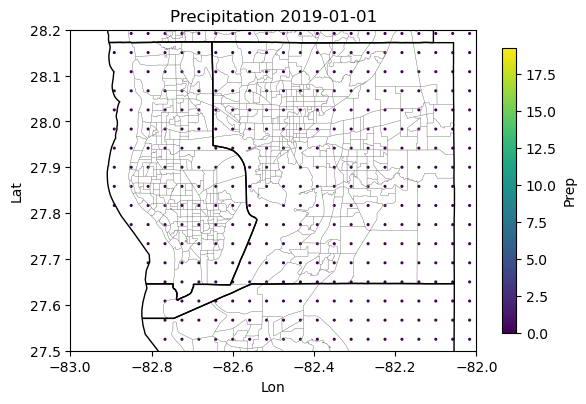

In [65]:
plt.figure(figsize=(6, 6))
ax = plt.subplot(1, 1, 1)

gdf.plot(column='precipitation_amount', s=1.5, legend=True, ax=ax, legend_kwds={'shrink': 0.5, 'label': 'Prep'})
tract.plot(facecolor='none', edgecolor='grey', linewidth=0.2, ax=ax)
county.plot(facecolor='none', edgecolor='black', linewidth=1, ax=ax)

ax.set_xlabel('Lon')
ax.set_ylabel('Lat')
ax.set_title('Precipitation 2019-01-01')

# Example Tampa
ax.set_xlim(-83, -82)
ax.set_ylim(27.5, 28.2)

plt.tight_layout()
plt.show()

## Extract values

In [124]:
variable_names = {
    'pr': 'precipitation_amount',
    'rmax': 'relative_humidity',
    'tmmn': 'air_temperature',
    'tmmx': 'air_temperature',
    'vs': 'wind_speed'
}

variable_column_names = {
    'pr': 'precipitation',
    'rmax': 'humidity',
    'tmmn': 'air_temperature_min',
    'tmmx': 'air_temperature_max',
    'vs': 'wind_speed'
}

def extract_values(var):
    all_data = []
    for year in range(2019, 2024):
        print(f'---- process year: {year}')
        # Open using xarray
        ds = xr.open_dataset(f"data/gridMET/{var}_{year}.nc") # The raw data is not uploaded to GitHub
        n = len(ds['day'].values)
        for geoid, target_lat, target_lon in zip(tract_centroids['GEOID'], tract_centroids['LAT'], tract_centroids['LON']):     
            index_lat = np.argmin(abs(ds['lat'].values - target_lat))
            index_lon = np.argmin(abs(ds['lon'].values - target_lon))
            val = ds[variable_names[var]].values[:, index_lat, index_lon]
            temp = pd.DataFrame({
                'GEOID': [geoid] * n,
                'day': [str(i)[:10] for i in ds['day'].values],
                variable_column_names[var]: val
            })
            all_data.append(temp)
    df = pd.concat(all_data)
    df = df.merge(week_table, on='day')
    df = df.groupby(['GEOID', 'week']).agg({variable_column_names[var]: 'mean'}).reset_index()
    df.to_csv(f'Data/gridMET/{var}.csv', header=True, index=False, quoting=csv.QUOTE_NONNUMERIC)

In [125]:
for var in ['pr', 'rmax', 'tmmn', 'tmmx', 'vs']:
    print(f'{'*'*20}\nVariable: {var}')
    extract_values(var)
    print('\n')

********************
Variable: pr
---- process year: 2019
---- process year: 2020
---- process year: 2021
---- process year: 2022
---- process year: 2023


********************
Variable: rmax
---- process year: 2019
---- process year: 2020
---- process year: 2021
---- process year: 2022
---- process year: 2023


********************
Variable: tmmn
---- process year: 2019
---- process year: 2020
---- process year: 2021
---- process year: 2022
---- process year: 2023


********************
Variable: tmmx
---- process year: 2019
---- process year: 2020
---- process year: 2021
---- process year: 2022
---- process year: 2023


********************
Variable: vs
---- process year: 2019
---- process year: 2020
---- process year: 2021
---- process year: 2022
---- process year: 2023




## Merge the datasets

In [149]:
df = pd.read_csv('data/gridMET/pr.csv', header=0, dtype={'GEOID': 'str'})[['GEOID', 'week']]
for var in ['pr', 'rmax', 'tmmn', 'tmmx', 'vs']:
    temp = pd.read_csv(f'Data/gridMET/{var}.csv', header=0, dtype={'GEOID': 'str'})
    df = df.merge(temp, on=['GEOID', 'week'])

In [150]:
df['air_temperature_min'] = df['air_temperature_min'] - 273.15
df['air_temperature_max'] = df['air_temperature_max'] - 273.15
df['air_temperature_avg'] = (df['air_temperature_max'] + df['air_temperature_min']) / 2

In [151]:
df

,GEOID,week,precipitation,humidity,air_temperature_min,air_temperature_max,wind_speed,air_temperature_avg
0,12005000201,2019-01-07,0.614286,88.257143,5.921429,19.335714,4.628571,12.628571
1,12005000201,2019-01-14,1.885714,88.442857,4.478571,15.492857,5.142857,9.985714
2,12005000201,2019-01-21,8.542857,87.814286,2.950000,15.764286,5.942857,9.357143
3,12005000201,2019-01-28,4.442857,83.728571,5.450000,16.278571,4.171429,10.864286
4,12005000201,2019-02-04,0.142857,81.971429,12.307143,22.650000,4.371429,17.478571
...,...,...,...,...,...,...,...,...
859295,12131990000,2023-11-27,19.571429,87.485714,10.135714,18.407143,5.114286,14.271429
859296,12131990000,2023-12-04,9.700000,87.885714,9.950000,18.421429,5.200000,14.185714
859297,12131990000,2023-12-11,0.600000,79.785714,9.207143,16.792857,7.742857,13.000000
859298,12131990000,2023-12-18,0.771429,88.314286,7.750000,17.207143,6.257143,12.478571


In [152]:
df.to_csv('data/Weather/Weather_Variables.csv', header=True, index=False, quoting=csv.QUOTE_NONNUMERIC)